In [ ]:
!pip install langdetect emoji contractions -q

import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00


In [ ]:

# Your exact raw link
url = "https://raw.githubusercontent.com/codebyzahra/RaayeAI/3bb2b471d3d12ddaeb1e2751855ca81b00610384/data/daraz-code-mixed-product-reviews.csv"

# Load the data
df = pd.read_csv(url)

# Check the first few rows
df.head()

,Sentiments,Reviews
0,negative,Stuff and design was totally changed. cheap qu...
1,positive,"i got my parxel before time,sorry for late rev..."
2,positive,So far so good..... Bought it only because it ...
3,neutral,Received as described but not suitable such ha...
4,positive,Received on time and in a safely packed box. T...


In [ ]:
# Map text labels to numbers
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['Label'] = df['Sentiments'].map(sentiment_mapping)

# Check the distribution to see if the dataset is balanced
print(df['Label'].value_counts())

Label
2    10167
0     4362
1     2461
Name: count, dtype: int64


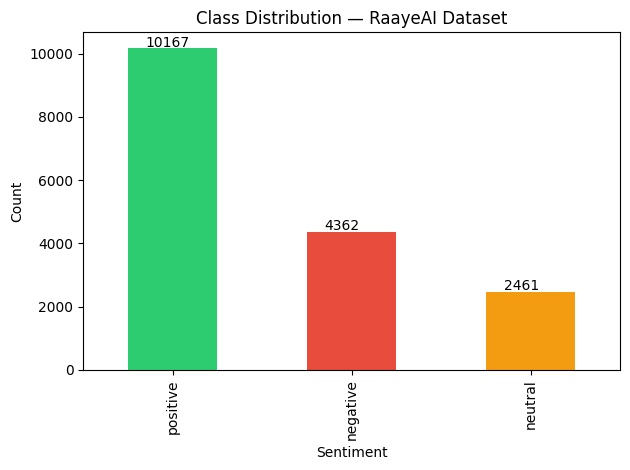

In [ ]:
ax = df['Sentiments'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c','#f39c12'])
plt.title('Class Distribution — RaayeAI Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x()+0.1, p.get_height()+50))
plt.tight_layout()
plt.savefig('class_distribution.png')  # save for README/report
plt.show()

In [ ]:
def preprocess_roman_urdu(text):
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Convert emojis to text description
    text = emoji.demojize(text, delimiters=(" ", " "))

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 5. Roman Urdu normalization (common spellings)
    roman_urdu_map = {
        r'\bachi\b': 'acha',
        r'\bachha\b': 'acha',
        r'\bacha\b': 'acha',
        r'\bbht\b': 'bohot',
        r'\bbhut\b': 'bohot',
        r'\bbhot\b': 'bohot',
        r'\bbohat\b': 'bohot',
        r'\bnhi\b': 'nahi',
        r'\bnay\b': 'ne',
        r'\bkafi\b': 'kaafi',
        r'\bthk\b': 'theek',
        r'\btheek\b': 'theek',
        r'\bthik\b': 'theek',
        r'\bkrna\b': 'karna',
        r'\bkr\b': 'kar',
        r'\bphr\b': 'phir',
        r'\bmje\b': 'mujhe',
        r'\bmjhe\b': 'mujhe',
        r'\baur\b': 'aur',
        r'\bor\b': 'aur',          # English 'or' vs Roman Urdu 'or' = aur
        r'\bgood\b': 'good',       # keep English as is
        r'\bbad\b': 'bad',
    }
    for pattern, replacement in roman_urdu_map.items():
        text = re.sub(pattern, replacement, text)

    # 6. Remove special characters but keep alphanumeric + spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply
df['Clean_Review'] = df['Reviews'].apply(preprocess_roman_urdu)
df[['Reviews', 'Clean_Review']].head(10)

,Reviews,Clean_Review
0,Stuff and design was totally changed. cheap qu...,stuff and design was totally changed cheap qua...
1,"i got my parxel before time,sorry for late rev...",i got my parxel before time sorry for late rev...
2,So far so good..... Bought it only because it ...,so far so good bought it only because it has t...
3,Received as described but not suitable such ha...,received as described but not suitable such ha...
4,Received on time and in a safely packed box. T...,received on time and in a safely packed box th...
5,satisfied 🤩,satisfied star struck
6,Seller is very cooperative plus sent the same ...,seller is very cooperative plus sent the same ...
7,checked this device in 3 cars at a time but no...,checked this device in 3 cars at a time but no...
8,good quality and fresh 👍 at given time,good quality and fresh thumbs up at given time
9,"not fresh, very small",not fresh very small


In [ ]:
# Compare before/after on random samples
sample_idx = df.sample(5).index
for i in sample_idx:
    print(f"ORIGINAL : {df.loc[i,'Reviews']}")
    print(f"CLEANED  : {df.loc[i,'Clean_Review']}")
    print("-"*60)

ORIGINAL : bohat acha product ha fast dilvery bhi ha taqreeban thank you daraz 
CLEANED  : bohot acha product ha fast dilvery bhi ha taqreeban thank you daraz
------------------------------------------------------------
ORIGINAL : Alhmdulillah satisfied, earphones are very nice
CLEANED  : alhmdulillah satisfied earphones are very nice
------------------------------------------------------------
ORIGINAL : very poor . too much disappointed
CLEANED  : very poor too much disappointed
------------------------------------------------------------
ORIGINAL : Alhumdolillah sab set behtareen
CLEANED  : alhumdolillah sab set behtareen
------------------------------------------------------------
ORIGINAL : the product is pretty cool but the size is a bit smaller than I expected.
CLEANED  : the product is pretty cool but the size is a bit smaller than i expected
------------------------------------------------------------


In [ ]:
from sklearn.utils import resample

# Separate classes
df_pos = df[df['Label'] == 2]
df_neg = df[df['Label'] == 0]
df_neu = df[df['Label'] == 1]

# Upsample minority classes to match majority
df_neg_upsampled = resample(df_neg, replace=True, n_samples=len(df_pos), random_state=42)
df_neu_upsampled = resample(df_neu, replace=True, n_samples=len(df_pos), random_state=42)

df_balanced = pd.concat([df_pos, df_neg_upsampled, df_neu_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Label'].value_counts())

Label
2    10167
1    10167
0    10167
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df_balanced['Clean_Review']
y = df_balanced['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 24400 | Test: 6101


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(24400, 10000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

              precision    recall  f1-score   support

    negative       0.92      0.94      0.93      2033
     neutral       0.90      0.93      0.91      2034
    positive       0.95      0.91      0.93      2034

    accuracy                           0.92      6101
   macro avg       0.92      0.92      0.92      6101
weighted avg       0.92      0.92      0.92      6101



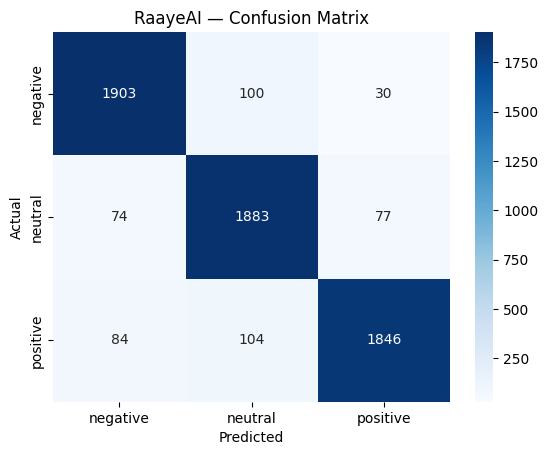

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title('RaayeAI — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

import joblib

# Create folder if not exists
os.makedirs('/content/drive/MyDrive/RaayeAI', exist_ok=True)

joblib.dump(lr, '/content/drive/MyDrive/RaayeAI/raayeai_lr_model.pkl')
joblib.dump(tfidf, '/content/drive/MyDrive/RaayeAI/raayeai_tfidf.pkl')
print("Saved to Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive!
